In [20]:
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
zhzi, hzi, shzi = np.genfromtxt('data/Hz33Clocks.txt', comments='#', usecols=(0,1,2), unpack=True)
zmod, imf, slib, sps, spsooo = np.genfromtxt('data/data_MM20.dat', comments='#', usecols=(0,1,2,3,4), unpack=True)
ndata = len(zhzi)

In [46]:
cov_mat_diag = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    cov_mat_diag[i,i] = shzi[i]**2

imf_intp = np.interp(zhzi, zmod, imf)/100
slib_intp = np.interp(zhzi, zmod, slib)/100
sps_intp = np.interp(zhzi, zmod, sps)/100
spsooo_intp = np.interp(zhzi, zmod, spsooo)/100

cov_mat_imf = np.zeros((ndata, ndata), dtype='float64')
cov_mat_slib = np.zeros((ndata, ndata), dtype='float64')
cov_mat_sps = np.zeros((ndata, ndata), dtype='float64')
cov_mat_spsooo = np.zeros((ndata, ndata), dtype='float64')

for i in range(ndata):
    for j in range(ndata):
        cov_mat_imf[i,j] = hzi[i] * imf_intp[i] * hzi[j] * imf_intp[j]
        cov_mat_slib[i,j] = hzi[i] * slib_intp[i] * hzi[j] * slib_intp[j]
        cov_mat_sps[i,j] = hzi[i] * sps_intp[i] * hzi[j] * sps_intp[j]
        cov_mat_spsooo[i,j] = hzi[i] * spsooo_intp[i] * hzi[j] * spsooo_intp[j]

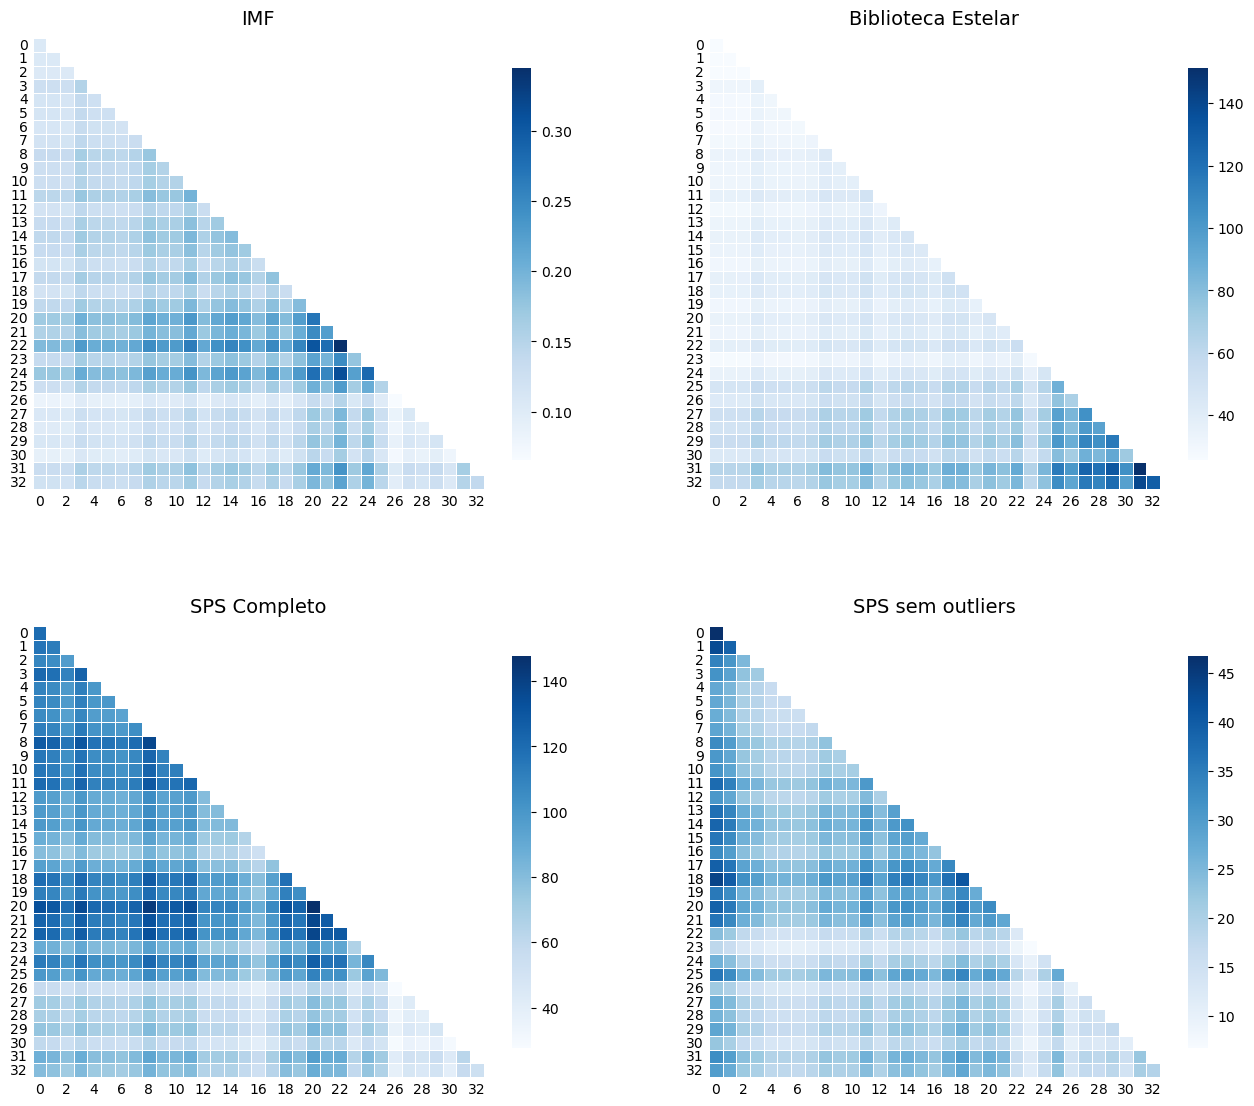

<Figure size 640x480 with 0 Axes>

In [103]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))
axes = axes.flatten()

# Máscara genérica (assumindo que todas as matrizes têm a mesma dimensão N x N)
mask = np.triu(np.ones_like(cov_mat_diag, dtype=bool), k=1)

matrizes = {
    #'Estatístico': cov_mat_diag, 
    'IMF': cov_mat_imf, 
    'Biblioteca Estelar': cov_mat_slib, 
    'SPS Completo': cov_mat_sps,
    'SPS sem outliers': cov_mat_spsooo
}

for ax, (titulo, matriz) in zip(axes, matrizes.items()):    
    sb.heatmap(matriz, 
                mask=mask,
                ax=ax,          # Injeção do objeto de eixo
                cmap='Blues',
                center=centro,
                annot=False, 
                square=True, 
                linewidths=.5,
                cbar_kws={"shrink": .8})
    
    ax.set_title(titulo, fontsize=14, pad=10)
    
    # Limpeza visual: remove os ticks internos se a malha for densa
    ax.tick_params(axis='both', which='both', length=0)

# Ajuste automático do espaçamento entre os subquadros para evitar sobreposição de legendas
plt.show()
plt.savefig('each_sys.pdf')

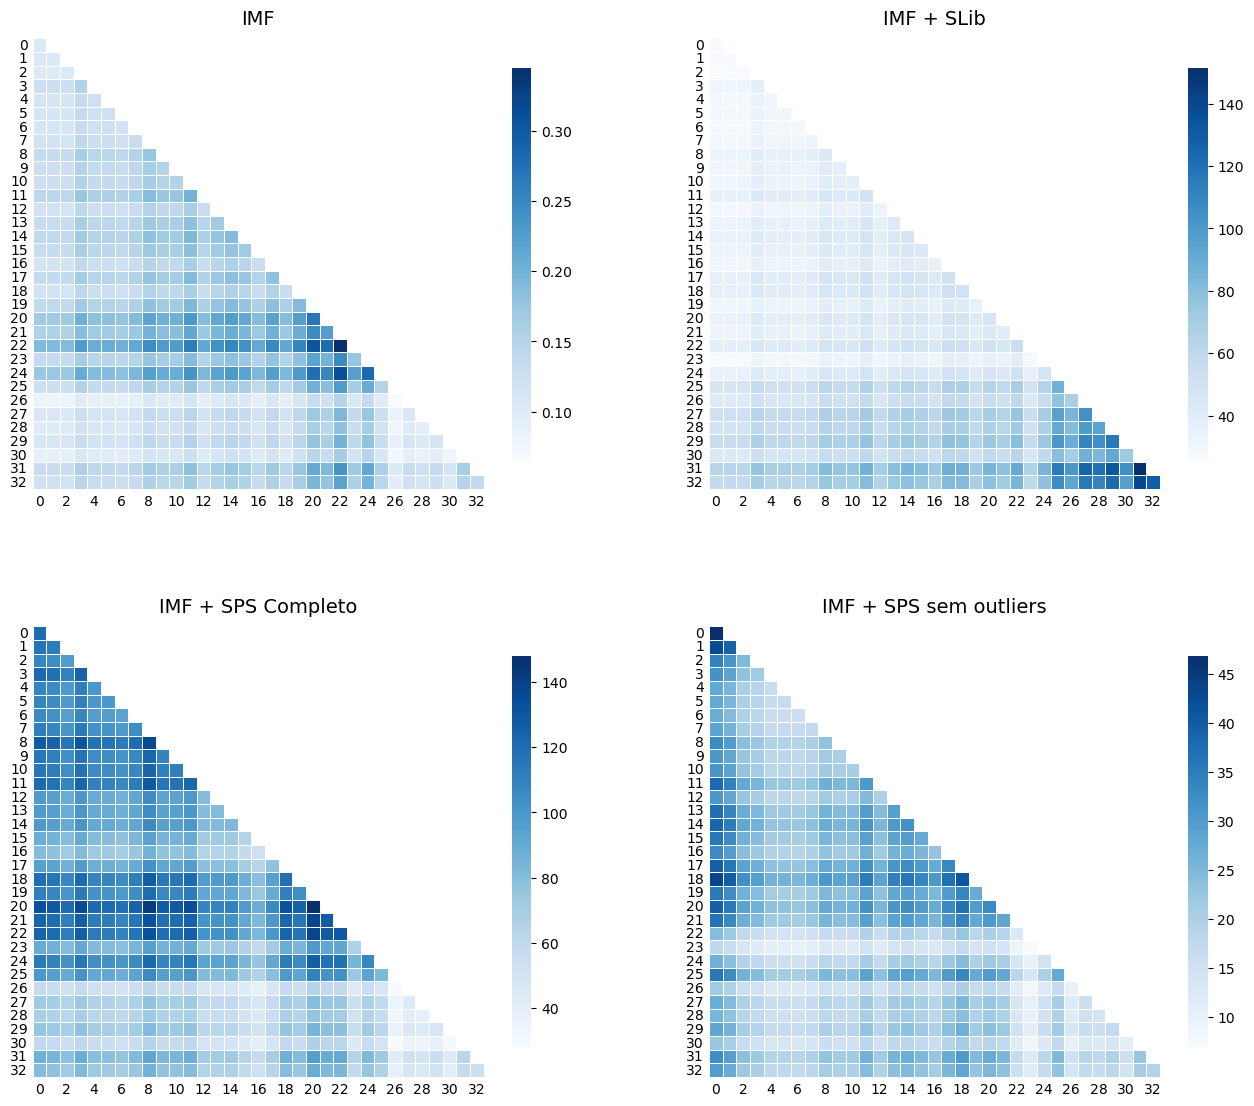

<Figure size 640x480 with 0 Axes>

In [102]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))
axes = axes.flatten()

# Máscara genérica (assumindo que todas as matrizes têm a mesma dimensão N x N)
mask = np.triu(np.ones_like(cov_mat_diag, dtype=bool), k=1)

matrizes = {
    #'Estatístico': cov_mat_diag, 
    'IMF': cov_mat_imf, 
    'IMF + SLib': cov_mat_slib + cov_mat_imf,
    'IMF + SPS Completo': cov_mat_sps + cov_mat_imf,
    'IMF + SPS sem outliers': cov_mat_spsooo + cov_mat_imf,
}

for ax, (titulo, matriz) in zip(axes, matrizes.items()):    
    sb.heatmap(matriz, 
                mask=mask,
                ax=ax,          # Injeção do objeto de eixo
                cmap='Blues',
                center=centro,
                annot=False, 
                square=True, 
                linewidths=.5,
                cbar_kws={"shrink": .8})
    
    ax.set_title(titulo, fontsize=14, pad=10)
    
    # Limpeza visual: remove os ticks internos se a malha for densa
    ax.tick_params(axis='both', which='both', length=0)

# Ajuste automático do espaçamento entre os subquadros para evitar sobreposição de legendas
plt.show()
plt.savefig('sys_effects.pdf')

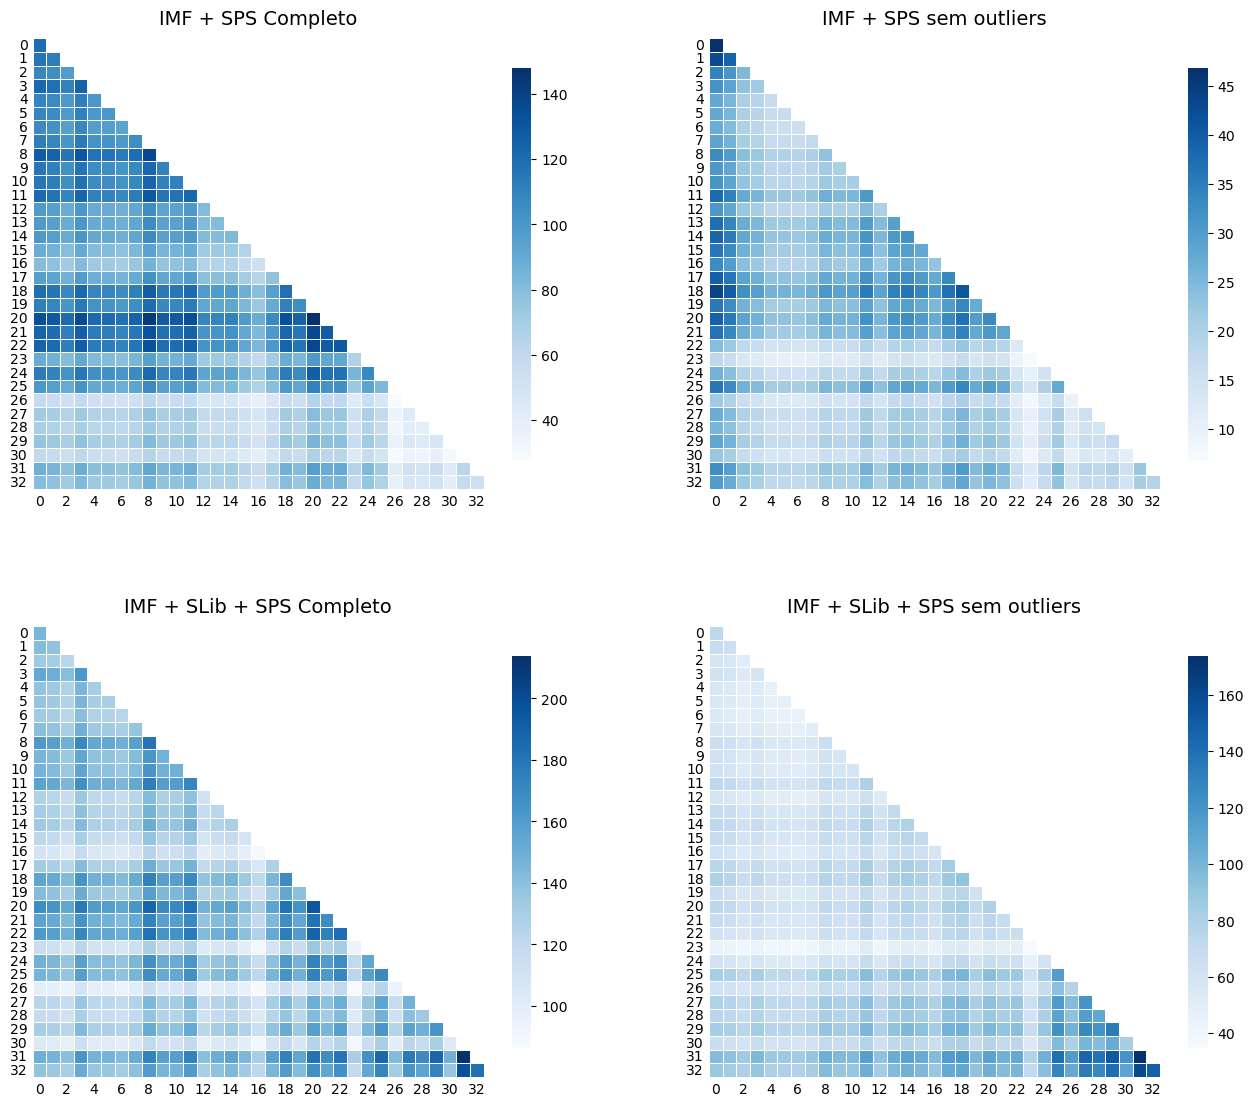

<Figure size 640x480 with 0 Axes>

In [105]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))
axes = axes.flatten()

# Máscara genérica (assumindo que todas as matrizes têm a mesma dimensão N x N)
mask = np.triu(np.ones_like(cov_mat_diag, dtype=bool), k=1)

matrizes = {
    'IMF + SPS Completo': cov_mat_sps + cov_mat_imf,
    'IMF + SPS sem outliers': cov_mat_spsooo + cov_mat_imf,
    'IMF + SLib + SPS Completo': cov_mat_sps + cov_mat_slib + cov_mat_imf,
    'IMF + SLib + SPS sem outliers': cov_mat_spsooo + cov_mat_slib + cov_mat_imf,
}

for ax, (titulo, matriz) in zip(axes, matrizes.items()):    
    sb.heatmap(matriz, 
                mask=mask,
                ax=ax,          # Injeção do objeto de eixo
                cmap='Blues',
                center=centro,
                annot=False, 
                square=True, 
                linewidths=.5,
                cbar_kws={"shrink": .8})
    
    ax.set_title(titulo, fontsize=14, pad=10)
    
    # Limpeza visual: remove os ticks internos se a malha for densa
    ax.tick_params(axis='both', which='both', length=0)

# Ajuste automático do espaçamento entre os subquadros para evitar sobreposição de legendas
plt.show()
plt.savefig('combinations_cov_matrix.pdf')

In [107]:
cov_mat_cons = cov_mat_diag + cov_mat_imf + cov_mat_slib + cov_mat_sps
cov_mat_lcons = cov_mat_diag + cov_mat_imf + cov_mat_slib + cov_mat_spsooo
cov_mat_rec = cov_mat_diag + cov_mat_imf + cov_mat_spsooo
cov_mat_lrec = cov_mat_diag + cov_mat_imf + cov_mat_sps

corr_mat_cons = np.zeros((ndata, ndata), dtype='float64')
corr_mat_lcons = np.zeros((ndata, ndata), dtype='float64')
corr_mat_rec = np.zeros((ndata, ndata), dtype='float64')
corr_mat_lrec = np.zeros((ndata, ndata), dtype='float64')
for i in range(ndata):
    for j in range(ndata):
        corr_mat_cons[i,j] = cov_mat_cons[i,j]/np.sqrt(cov_mat_cons[i,i] * cov_mat_cons[j,j])
        corr_mat_lcons[i,j] = cov_mat_lcons[i,j]/np.sqrt(cov_mat_lcons[i,i] * cov_mat_lcons[j,j])
        corr_mat_rec[i,j] = cov_mat_rec[i,j]/np.sqrt(cov_mat_rec[i,i] * cov_mat_rec[j,j])
        corr_mat_lrec[i,j] = cov_mat_lrec[i,j]/np.sqrt(cov_mat_lrec[i,i] * cov_mat_lrec[j,j])

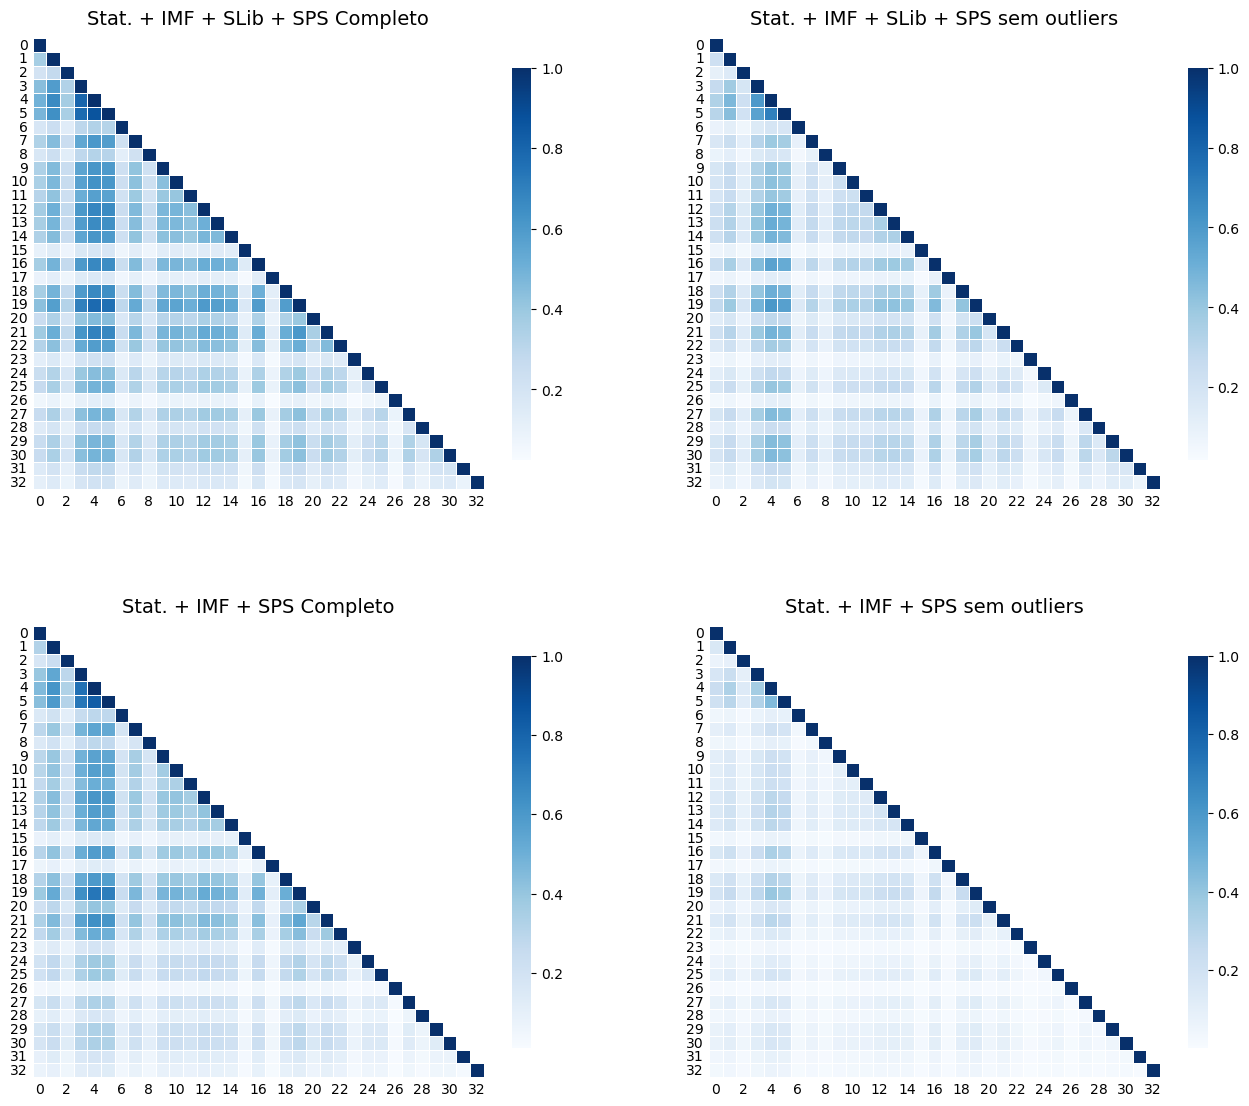

<Figure size 640x480 with 0 Axes>

In [109]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 14))
axes = axes.flatten()

# Máscara genérica (assumindo que todas as matrizes têm a mesma dimensão N x N)
mask = np.triu(np.ones_like(cov_mat_diag, dtype=bool), k=1)

matrizes = {
    'Stat. + IMF + SLib + SPS Completo': corr_mat_cons,
    'Stat. + IMF + SLib + SPS sem outliers': corr_mat_lcons,
    'Stat. + IMF + SPS Completo': corr_mat_lrec,
    'Stat. + IMF + SPS sem outliers': corr_mat_rec,
}

for ax, (titulo, matriz) in zip(axes, matrizes.items()):    
    sb.heatmap(matriz, 
                mask=mask,
                ax=ax,          # Injeção do objeto de eixo
                cmap='Blues',
                center=centro,
                annot=False, 
                square=True, 
                linewidths=.5,
                cbar_kws={"shrink": .8})
    
    ax.set_title(titulo, fontsize=14, pad=10)
    
    # Limpeza visual: remove os ticks internos se a malha for densa
    ax.tick_params(axis='both', which='both', length=0)

# Ajuste automático do espaçamento entre os subquadros para evitar sobreposição de legendas
plt.show()
plt.savefig('corr_matrix.pdf')

In [117]:
diag_sps = cov_mat_diag + cov_mat_sps + cov_mat_imf
diag_spsooo = cov_mat_diag + cov_mat_spsooo + cov_mat_imf
diag_sps_slib = cov_mat_diag + cov_mat_sps + cov_mat_slib + cov_mat_imf
diag_spsooo_slib = cov_mat_diag + cov_mat_spsooo + cov_mat_slib + cov_mat_imf

In [115]:
autovalores_sps, autovetores_sps = np.linalg.eigh(diag_sps)
autovalores_spsooo, autovetores_spsooo = np.linalg.eigh(diag_spsooo)

autovalor_max_sps = np.max(autovalores_sps)
autovalor_max_spsooo = np.max(autovalores_spsooo)

autovetor_sps = autovetores_sps[np.where(autovalores_sps == autovalor_max_sps)[0]]
autovetor_spsooo = autovetores_spsooo[np.where(autovalores_spsooo == autovalor_max_spsooo)[0]]

print(autovalor_max_sps)
print(autovalor_max_spsooo)
print(autovetor_sps)
print(autovetor_spsooo)

4444.81903236627
4238.955864567307
[[-7.71831569e-04  1.79228409e-03 -2.08632013e-06 -1.55258273e-03
  -1.94485887e-03 -1.55302928e-03 -1.09110155e-03 -3.90832016e-06
   1.58372182e-03  2.75581558e-04  1.14675696e-03  1.10449854e-03
  -1.57718614e-16 -3.11819418e-06  4.78838538e-03 -3.31219376e-17
   1.31954559e-06 -1.79615885e-03 -4.79760441e-03 -1.60913362e-03
   8.03295382e-03  9.56928547e-03 -4.94955466e-03  1.28102207e-02
  -2.09849595e-02  3.65222624e-02 -4.24876469e-02 -6.64419404e-09
   4.46004311e-01 -8.01295446e-01 -3.63845640e-01  8.84900261e-02
  -1.21642926e-01]]
[[-8.92172436e-04  1.52362780e-03 -1.57962555e-08 -1.57495458e-03
  -1.89313549e-03 -1.44044469e-03 -1.20557205e-03  4.83993665e-06
   1.68868709e-03  2.78863232e-04  1.19370578e-03  1.43116904e-03
  -1.53503475e-16  1.01884428e-08  6.36112463e-03 -2.09462239e-17
  -7.52025514e-06 -3.38642074e-03 -6.26068139e-03 -1.70974712e-03
   1.20794979e-02 -1.43537294e-02 -7.58182320e-03  2.83661931e-02
  -3.27023351e-02  2.

In [118]:
autovalores_sps_slib, autovetores_sps_slib = np.linalg.eigh(diag_sps_slib)
autovalores_spsooo_slib, autovetores_spsooo_slib = np.linalg.eigh(diag_spsooo_slib)

autovalor_max_sps_slib = np.max(autovalores_sps_slib)
autovalor_max_spsooo_slib = np.max(autovalores_spsooo_slib)

autovetor_sps_slib = autovetores_sps_slib[np.where(autovalores_sps_slib == autovalor_max_sps_slib)[0]]
autovetor_spsooo_slib = autovetores_spsooo_slib[np.where(autovalores_spsooo_slib == autovalor_max_spsooo_slib)[0]]

print(autovalor_max_sps_slib)
print(autovalor_max_spsooo_slib)
print(autovetor_sps_slib)
print(autovetor_spsooo_slib)

5673.199310951542
4531.081689175411
[[-4.35807064e-04  9.59244007e-04 -3.28429479e-04 -3.88040162e-04
  -2.70118830e-03 -1.56901023e-03 -2.36756351e-03  7.06512772e-04
   3.58762331e-04 -9.23539449e-04 -1.32222797e-03 -5.35717327e-04
  -2.35729408e-09 -6.26878907e-03  2.62812921e-03 -2.87532895e-07
  -4.83486470e-03  4.78120974e-03 -1.08453598e-02  9.45117193e-03
  -1.34807877e-02  1.76703724e-02  1.00306888e-02 -1.78427220e-02
   1.62099414e-02 -4.92512308e-02  4.04697452e-02  1.16659128e-02
   5.24270302e-01 -7.68381787e-01 -2.41287487e-01  7.85365713e-02
  -2.54258745e-01]]
[[-1.57255903e-03  2.98254916e-03 -4.74434892e-04  2.35061310e-03
  -2.99131720e-03 -2.50669241e-03 -2.10000790e-03  1.28740996e-03
  -8.83898141e-04 -5.25371099e-04 -3.54461896e-04 -6.13649349e-04
  -5.24548548e-17  2.22049416e-03  6.70457284e-03  1.41368407e-05
  -1.43879971e-03 -3.36411882e-03 -1.03658747e-02  2.38494708e-03
  -1.19748944e-02  1.98185972e-02  1.19329399e-02 -2.83782325e-02
   5.80364400e-02 -6

In [121]:
import numpy as np

# 1. Amplificação da Variância (Razão dos Autovalores Máximos)
razao_amplificacao = autovalor_max_sps / autovalor_max_spsooo

# 2. Alinhamento Espacial (Produto Interno dos Autovetores)
# A função np.linalg.eigh retorna vetores normalizados (norma Euclidiana = 1).
# O produto interno direto fornece o cosseno do ângulo entre eles.
# Usa-se o valor absoluto pois o sinal do autovetor extraído é algebricamente arbitrário.
cos_theta = np.abs(np.dot(autovetor_sps, autovetor_spsooo.T))
angulo_graus = np.degrees(np.arccos(cos_theta))

# 3. Dominância do Componente Principal (Traço da Matriz)
traco_sps = np.sum(autovalores_sps)
traco_spsooo = np.sum(autovalores_spsooo)

fracao_variancia_sps = autovalor_max_sps / traco_sps
fracao_variancia_spsooo = autovalor_max_spsooo / traco_spsooo

print(f"Razão de Amplificação: {razao_amplificacao:.4f}")
print(f"Cosseno do Ângulo: {cos_theta} ({angulo_graus} graus)")
print(f"Fração da Variância Dominante (SPS): {fracao_variancia_sps:.4f}")
print(f"Fração da Variância Dominante (SPSooo): {fracao_variancia_spsooo:.4f}")

Razão de Amplificação: 1.0486
Cosseno do Ângulo: [[0.66647937]] ([[48.2040814]] graus)
Fração da Variância Dominante (SPS): 0.1572
Fração da Variância Dominante (SPSooo): 0.1626
